In [1]:
import openpyxl
import pandas as pd
import numpy as np
import statistics
import scipy.stats as stats
import math
import seaborn as sns

from statsmodels.stats.multitest import multipletests

#from google.colab import files

%pylab inline
import matplotlib.patches as mpatches

import warnings
warnings.filterwarnings('ignore')

pd.options.display.max_rows = None

%config InlineBackend.figure_format='retina'

Populating the interactive namespace from numpy and matplotlib


In [2]:
plt.rcParams.update({'font.sans-serif':'Arial'})

x_font = {'size':'16', 'family':'Arial'}
y_font = {'size':'16', 'family':'Arial'} #14 for main
title_font = {'size':'18'} # Bottom vertical alignment for more space 

#'color':'black', 'weight':'normal',
#             'verticalalignment':'bottom'

In [11]:
# CHOOSE IF YOU WANT TO SAVE AND DOWNLOAD FILES/FIGURES HERE

#saveFiles = True
saveFiles = False

#downloadFiles = True
downloadFiles = False

#saveFigures = True
saveFigures = False

#downloadFigures = True
downloadFigures = False

In [7]:
# DEFINE CONSTANTS

suppFig = False
#suppFig = True

toPlotOnX = 'Biogroup' #'Biogroup' or 'Cell Line'
toColor = 'Cell Line' #'Biogroup' or 'Cell Line'
# CHANGE DEPENDING ON WHETHER WANT TO PLOT NORMALIZED QUANTITY OR RELATIVE EXPRESSION
#toPlotOnY = 'quantity_normalized'
#forFigureName = 'quantityNormalized'
toPlotOnY = 'Relative Expression (to H20961 iPS)'
forFigureName = 'Relative Expression (to H2 iPSC)'


onlyTwoTissues = True
onlyTwoTissues = False

tissueTypes_dict = {'NANOG':['pluri', 'ecto', 'meso', 'endo'], 'DNMT3B':['pluri', 'ecto', 'meso', 'endo'],
               'PAX6':['pluri', 'ecto'], 'RAX':['pluri', 'ecto'], 'DLK1':['pluri','ecto'], 'TUBB3':['pluri','ecto'],
               'TBXT':['pluri', 'meso'], 'TBXT':['pluri', 'meso'], 'HAND1':['pluri', 'meso'],
               'GSC':['pluri', 'endo'], 'FOXA2':['pluri', 'endo'], 'SOX17':['pluri', 'endo'], 'EOMES':['pluri', 'endo'], 'GATA4':['pluri', 'endo']}

errorBarWidth = 1.5
samplesToRemove = ['ecto-10', 'ecto-14', 'endo-7', 'endo-10']

if suppFig:
    samplesToRemove = ['ecto', 'meso', 'ecto-10', 'ecto-14']

#plottingOrder = {'H23555':'#AA0000', 'H20961':'#FF0000', 'H23555 F8 fusion':'#FF5555', 'H23555 F9 fusion':'#FFAAAA', 
#                  'C3649K':'#0044AA','C8861':'#0066FF',  'C3649K fusion 2-3':'#5599FF', 'C3649K fusion 18-1':'#AACCFF', 
#                 'C3649K-H23555 C7':'#5A2CA0', 'C3649K-H23555 D6':'#8D5FD3','C8861-H20961 A9':'#AA87DE', 'C8861-H20961 G5':'#C6AFE9', 'C3649K-H23555 C7-47-F2':'#FF2AD4'}
### human red, chimp blue (INCORRECT, this is what was put in the published figure)
#plottingOrder = {'H23555':'#AA0000', 'H20961':'#FF0000', 'H23555 F8 fusion':'#FF5555', 'H23555 F9 fusion':'#FFAAAA', 
#                  'C3649K':'#0044AA','C8861':'#0066FF',  'C3649K fusion 2-3':'#5599FF', 'C3649K fusion 18-1':'#AACCFF', 
#                 'H23555-C3649K C7':'#892CA0', 'C3649K-H23555 D6':'#BC5FD3','C8861-H20961 A9':'#CD87DE', 'C8861-H20961 G5':'#DDAFE9', 'H23555-C3649K C7-47-F2':'#FF2AD4'}
### human blue, chimp red (CORRECT, for presentations and such)
plottingOrder = {'H23555':'#0044AA', 'H20961':'#0066FF', 'H23555 F8 fusion':'#5599FF', 'H23555 F9 fusion':'#AACCFF', 
                  'C3649K':'#AA0000','C8861':'#FF0000',  'C3649K fusion 2-3':'#FF5555', 'C3649K fusion 18-1':'#FFAAAA', 
                 'H23555-C3649K C7':'#892CA0', 'C3649K-H23555 D6':'#BC5FD3','C8861-H20961 A9':'#CD87DE', 'C8861-H20961 G5':'#DDAFE9', 'H23555-C3649K C7-47-F2':'#FF2AD4'}                 
#fluorescent line possibilities '#D35FBC' '#FF2AD4'

paletteForAll = sns.color_palette(list(plottingOrder.values())) 

cellLineNames_dict = {'H23555':'H1', 'H20961':'H2', 'H23555 F8 fusion':'H1H1a', 'H23555 F9 fusion':'H1H1b', 
                      'C3649K':'C1','C8861':'C2',  'C3649K fusion 2-3':'C1C1a', 'C3649K fusion 18-1':'C1C1c', 
                      'H23555-C3649K C7':'H1C1a', 'C3649K-H23555 D6':'H1C1b','C8861-H20961 A9':'H2C2a', 'C8861-H20961 G5':'H2C2b', 'H23555-C3649K C7-47-F2':'H1C1a-X1'}


if suppFig:
    #original colors (for plotting tissue type together)
    if toColor == 'Cell Line':
        plottingOrder = {'H23555 F9 fusion':'#FFAAAA', 
                     'H23555-C3649K C7':'#892CA0', 
                     'H23555-C3649K C7-47-F2':'#FF2AD4'}
    
    if toColor == 'Biogroup':
        plottingOrder = {'iPS':'#A5A7A9',
                  'H23555 F9 fusion':'#04C5C7', 
                 'H23555-C3649K C7':'orange', ##DB7400
                 'H23555-C3649K C7-47-F2':'yellowgreen'} ##D3CF04

    paletteForAll = sns.color_palette(list(plottingOrder.values())) 

    cellLineNames_dict = {'H23555 F9 fusion':'H1H1b', 
                      'H23555-C3649K C7':'H1C1a', 
                      'H23555-C3649K C7-47-F2':'H1C1a-X1'}

####################
    
#paletteColors = ['#ED1C24', '#2E3092', '#4A2668'] # Rachel's selection of red, blue, purple

#paletteColorsRed = ['#AA0000', '#FF0000','#FF5555','#FFAAAA']
#paletteColorsBlue = ['#0044AA','#0066FF','#5599FF','#AACCFF']
#paletteColorsPurple = ['#4400AA','#6600FF','#9955FF','#CCAAFF']
#paletteColorsPurple = ['#5A2CA0','#8D5FD3','#AA87DE','#C6AFE9']
#paletteColorsPurple = ['#892CA0','#BC5FD3','#CD87DE','#DDAFE9']
#paletteColors = paletteColorsRed[:2] + paletteColorsBlue[:2] + paletteColorsRed[2:] + paletteColorsBlue[2:] + paletteColorsPurple
#paletteForAll = sns.color_palette(paletteColors)

#paletteForAll = 'Set3'
#paletteForAll = sns.color_palette("husl", 14)
#paletteForAll = sns.color_palette("hls", 14)
#paletteForAll = 'Set1'
#paletteForAll = 'Set2'

In [8]:
# OPTIONS FOR WHAT TO PLOT ARE IN THIS CELL

# CHANGE "ALL_filename"
#   TO THE MANUALLY CURATED EXCEL FILE 
#   THAT CONTAINS ALL CELL LINES AND GENES
# THIS FILE MUST BE "samples" NOT "biogroups"

ALL_fileName = 'ALL_normalizedQuantity_samples_ALLcellLines.xlsx'

# CHANGE TO ALTER THE SCALE OF THE BROKEN Y AXIS
# Use for normalized quantity
#brokenY_axis_limits = {'PAX6'  :  (0, 0.44, 1.3, 13),
#                       'TBXT'  :  (0, 0.4, 0.8, 10.5),
#                       'HAND1' :  (0, 1.75, 2.2, 21),
#                       'FOXA2' :  (0, 1.2, 3, 14.5),
#                       'GSC'   :  (0, 0.85, 1.8, 37)}
# Use for relative gene expression (to H20961 iPS)
if not onlyTwoTissues:
    brokenY_axis_limits = {'PAX6'  :  (0, 600, 800, 8300),
                    'TBXT'  :  (0, 90, 100, 1000),
                    'HAND1' :  (0, 300, 300, 2100),
                    'FOXA2' :  (0, 90, 160, 700),
                    'GSC'   :  (0, 180, 260, 7100),
                     'RAX' : (0,75, 200, 3500),
                     'EOMES' : (0,15,50,380),
                     'SOX17':(0,660,1800,10200)}
                    #'GSC'   :  (0, 150, 200, 6800)
                    #'PAX6'  :  (0, 150, 300, 8100)
                    #'PAX6'  :  (0, 600, 800, 8100)
if onlyTwoTissues:
    brokenY_axis_limits = {'PAX6'  :  (0, 150, 400, 8200),
                    'TBXT'  :  (0, 60, 70, 1030),
                    'HAND1' :  (0, 300, 300, 2100),
                    'FOXA2' :  (0, 90, 160, 700),
                    'GSC' : (0,180,260,7100)}
                   # 'GSC'   :  (0, 15, 70, 7600)
                    #'GSC'   :  (0, 30, 40, 7600)
                    #'GSC'   :  (0, 150, 200, 6800)
    brokenY_axis_limits = {'PAX6'  :  (0, 15, 400, 8200),
                    'TBXT'  :  (0, 3, 40, 1030),
                    'HAND1' :  (0, 300, 300, 2100),
                    'FOXA2' :  (0, 75, 90, 700),
                    'GSC' : (0,180,260,7100),
                     'RAX' : (0,100, 400, 4000),
                     'EOMES' : (0,500,2000,8500),
                     'SOX17':(0,500,2000,4500)}
# CHANGE TO ALTER THE NUMBER OF COLUMNS IN THE LEGEND
#num_cols_in_legend = 8
#num_cols_in_legend = 13
num_cols_in_legend = 1

####### DON'T CHANGE BELOW HERE ########
plotting_df = pd.read_excel(ALL_fileName)

# remove longer differentiation time samples
for biogroup in samplesToRemove:
    plotting_df = plotting_df[plotting_df.Biogroup != biogroup]

# rename TBXT to Brachyury
#plotting_df = plotting_df.replace({'TBXT':'Brachyury'})

# get list of all included genes
genes = list(set(plotting_df['Target']))
print(genes)

# replace "C8861-H20961 G5" pluri and ecto samples with "C8861-H20961 G5 repeat" pluri and ecto samples
for gene in genes:
    plotting_df = plotting_df[~((plotting_df['Target']==gene) & (plotting_df['Cell Line']=='C8861-H20961 G5') & ((plotting_df['Biogroup']=='pluri') | (plotting_df['Biogroup']=='ecto')))]
plotting_df = plotting_df.replace({'C8861-H20961 G5 repeat':'C8861-H20961 G5'})

# make correct plotting order of cell lines
temp_df = pd.DataFrame()
for gene in genes:
    if not onlyTwoTissues:
        for cellLine in plottingOrder:
            temp_df = pd.concat([temp_df, plotting_df[(plotting_df['Target']==gene) & (plotting_df['Cell Line']==cellLine)]])
    if onlyTwoTissues:
        for cellLine in plottingOrder:
            for tissue in tissueTypes_dict[gene]:
                temp_df = pd.concat([temp_df, plotting_df[(plotting_df['Target']==gene) & (plotting_df['Cell Line']==cellLine) & (plotting_df['Biogroup']==tissue)]])
plotting_df = temp_df.copy()


####################

# replace certain labels/words with others
#plotting_df = plotting_df.replace({'pluri':'iPSC',
#                                   'ecto':'ectoderm',
#                                   'endo':'endoderm',
#                                   'meso':'mesoderm'})
plotting_df = plotting_df.replace({'pluri':'iPSC'})

# replace complicated cell line names (i.e. H23555) with simple names (i.e. H1)
plotting_df = plotting_df.replace(cellLineNames_dict)

if suppFig:
    plotting_df = plotting_df.replace({'pluri':'iPSC',
                                   'endo':'5-day',
                                   'endo-7':'7-day',
                                   'endo-10':'10-day'})
    
plottingType = 'Biogroup'

cellLines = []
for cellLine in plotting_df['Cell Line']:
    if cellLine not in cellLines:
        cellLines.append(cellLine)
#cellLines = list(set(plotting_df['Cell Line']))
print(cellLines)

# REMOVE ecto3 SAMPLES FROM C8861-H20961 G5
#indexNames = plotting_df[(plotting_df['Sample'] == 'ecto3') & (plotting_df['Cell Line'] == 'C8861 H20961 G5')].index
#plotting_df = plotting_df.drop(indexNames)

plotting_df.head()

['PAX6', 'TUBB3', 'DNMT3B', 'NANOG', 'SOX17', 'DLK1', 'FOXA2', 'HAND1', 'TBXT', 'GATA4', 'RAX', 'GSC', 'EOMES']
['H1', 'H2', 'H1H1a', 'H1H1b', 'C1', 'C2', 'C1C1a', 'C1C1c', 'H1C1a', 'H1C1b', 'H2C2a', 'H2C2b', 'H1C1a-X1']


,Sample,Target,Task,Cell Line,Sample Number,Sample+Target,Biogroup,efficiency,amp_factor,slope,...,Cq_housekeeping_geomMean,quantity_housekeeping_geomMean,Cq_housekeeping_geomMean - Cq_mean,ampFactor^Cq_housekeeping_geomMean - Cq_mean,quantity_normalized,H20961_iPS_mean_quantity_normalized,Relative Expression (to H20961 iPS),original_order,cell line order,tissue type order
935,pluri1,PAX6,UNKNOWN,H1,42.0,pluri1_PAX6,iPSC,106.197615,2.061976,-3.181839,...,19.169702,31.345147,-18.198954,1.907070e-06,0.000720,0.001532,0.470289,142.0,2.0,1.0
936,pluri2,PAX6,UNKNOWN,H1,43.0,pluri2_PAX6,iPSC,106.197615,2.061976,-3.181839,...,20.365300,13.825501,-17.387512,3.430754e-06,0.000715,0.001532,0.467037,143.0,2.0,1.0
937,pluri3,PAX6,UNKNOWN,H1,44.0,pluri3_PAX6,iPSC,106.197615,2.061976,-3.181839,...,20.047097,17.313979,-19.952903,5.359558e-07,0.000013,0.001532,0.008384,144.0,2.0,1.0
938,ecto1,PAX6,UNKNOWN,H1,33.0,ecto1_PAX6,ecto,106.197615,2.061976,-3.181839,...,20.301060,14.359641,-2.051412,2.266078e-01,5.450993,0.001532,3558.602020,133.0,2.0,2.0
939,ecto2,PAX6,UNKNOWN,H1,34.0,ecto2_PAX6,ecto,106.197615,2.061976,-3.181839,...,20.225499,15.256523,-1.586572,3.172242e-01,7.606559,0.001532,4965.832626,134.0,2.0,2.0


In [9]:
# function to make broken bar plot

def broken_y_bar_ALLcellLines(plotting_df, bottomAxisLower, bottomAxisUpper, topAxisLower, topAxisUpper, gene):

    f, (ax1, ax2) = plt.subplots(ncols=1, nrows=2, sharex=True)

    #f.text(-0.02, 0.5, forFigureName, va='center', ha='center', rotation='vertical', fontsize=rcParams['axes.labelsize'])

    ax1 = sns.barplot(x=toPlotOnX, y=toPlotOnY, hue=toColor, data=plotting_df, 
                    ax=ax1, ci='sd', palette=paletteForAll, errwidth=errorBarWidth, zorder=5, edgecolor=".2")

    #if plottingType == 'Biogroup':
    #  bottomAxisLower = 0
    #  bottomAxisUpper = list(plotting_df[errorMax].sort_values(ascending=False))[1] * 1.5
    #  topAxisLower = list(plotting_df[errorMin].sort_values(ascending=False))[0] * 0.8
    #  topAxisUpper = list(plotting_df[errorMax].sort_values(ascending=False))[0] * 1.05

    #if plottingType == 'Sample':
    #  bottomAxisLower = 0
    #  bottomAxisUpper = list(plotting_df[toPlotOnY].sort_values(ascending=False))[3] * 1.5
    #  topAxisLower = list(plotting_df[toPlotOnY].sort_values(ascending=False))[2] * 0.8
    #  topAxisUpper = list(plotting_df[toPlotOnY].sort_values(ascending=False))[0] * 1.05

    #print(maxValue)
    #print(secondMaxValue)
    #bottomAxisLower = 0
    #bottomAxisUpper = secondMaxValue * 1.1
    #topAxisLower = maxValue *.9
    #topAxisUpper = maxValue * 1.1

    #if plottingType == 'Biogroup':
    #  ax1.vlines(x=plotting_df[plottingType], ymin=plotting_df[errorMin], ymax=plotting_df[errorMax])

    ax1.set_ylim(topAxisLower,topAxisUpper)
    ax1.set_yticks(np.arange(round(topAxisLower), round(topAxisUpper), round((topAxisUpper-topAxisLower)/3)))
    #plt.xticks(rotation=90)
    ax1.set_xlabel('')
    ax1.set_title(gene, fontsize=18, style='italic')
    



    ax2 = sns.barplot(x=toPlotOnX, y=toPlotOnY, hue=toColor, data=plotting_df, 
                    ax=ax2, ci='sd', palette=paletteForAll, errwidth=errorBarWidth, zorder=5, edgecolor=".2")

    #if plottingType == 'Biogroup':  
    #  ax2.vlines(x=plotting_df[plottingType], ymin=plotting_df[errorMin], ymax=plotting_df[errorMax])

    ax2.set_ylim(bottomAxisLower, bottomAxisUpper)
    ax2.set_yticks(np.arange(0, round(bottomAxisUpper), round((bottomAxisUpper-bottomAxisLower)/3)))
    ax2.set_xlabel('')
    ax2.set_title('')

    ax1.tick_params(bottom=False)
    ax1.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    #d = .015  # how big to make the diagonal lines in axes coordinates
    d=0.01
    # arguments to pass to plot, just so we don't keep repeating them
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

    kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

    #ax2.set_ylabel(forFigureName)
    ax2.set_ylabel('')
    ax1.set_ylabel('')

    ax2.get_legend().remove()
    #ax1.legend(bbox_to_anchor=(1.03,1), loc="upper left")
    #ax1.legend(loc="upper left")
    ax1.get_legend().remove()
    #bbox_to_anchor=(0.5, -0.15),

    plt.subplots_adjust(wspace=0, hspace=.1)
    
    
    
    ax1.tick_params(axis='y', labelsize=14)
    ax2.tick_params(axis='y', labelsize=14)
    
    #ax1.tick_params(axis='y', labelsize=14)
    ax2.tick_params(axis='x', labelsize=16)


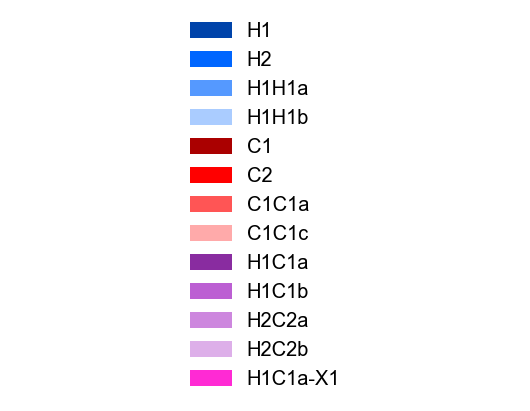

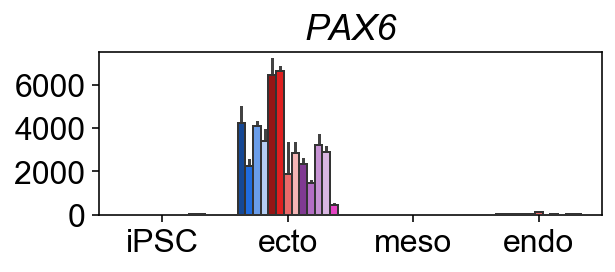

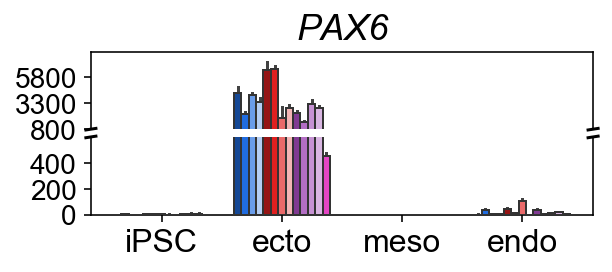

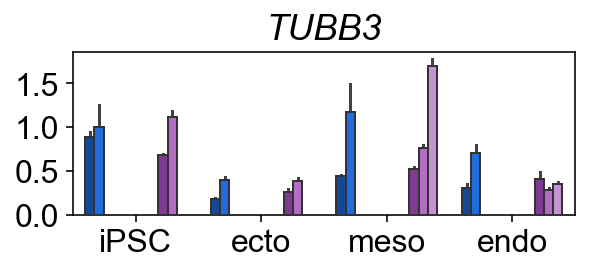

<Figure size 324x108 with 0 Axes>

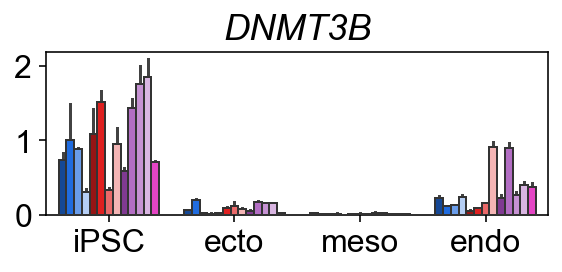

<Figure size 324x108 with 0 Axes>

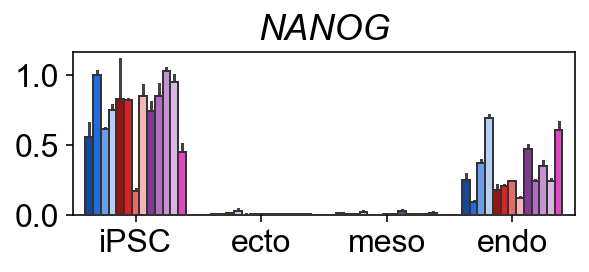

<Figure size 324x108 with 0 Axes>

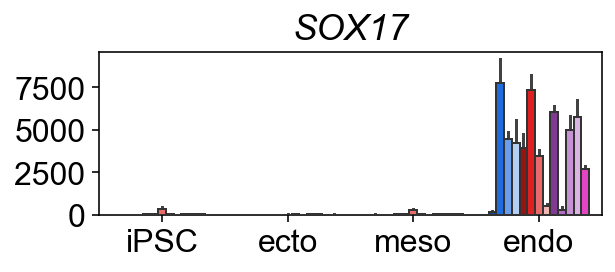

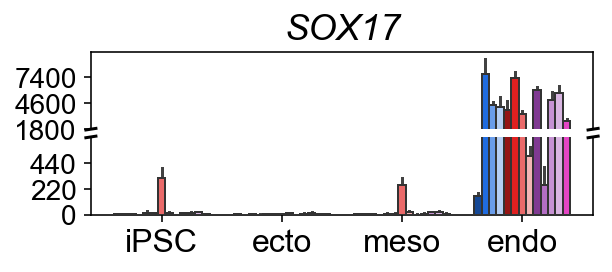

<Figure size 324x108 with 0 Axes>

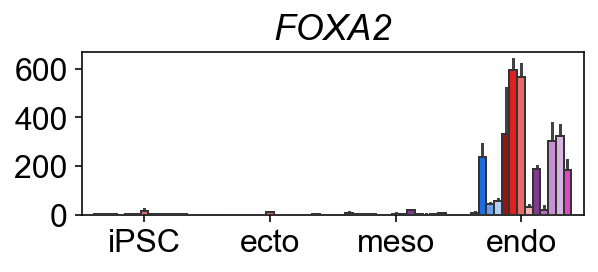

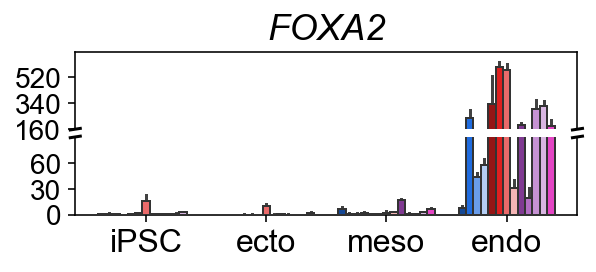

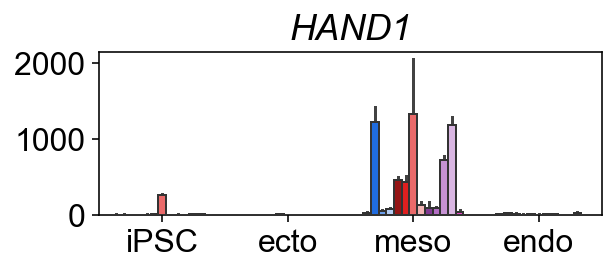

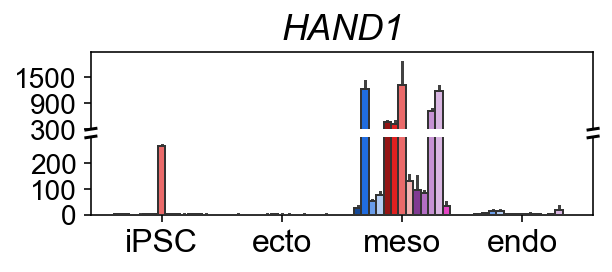

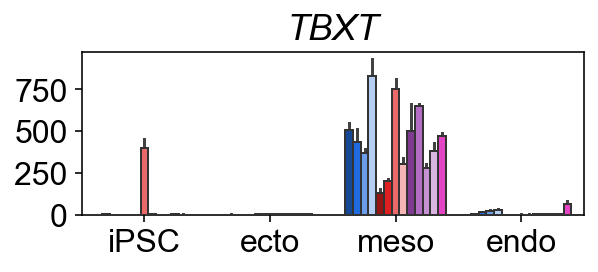

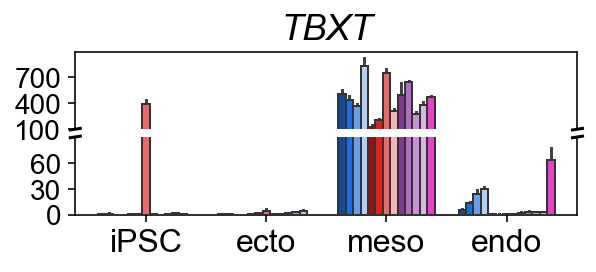

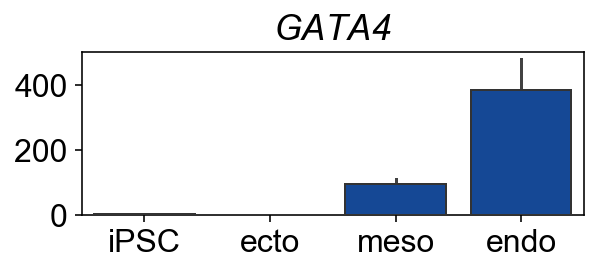

<Figure size 324x108 with 0 Axes>

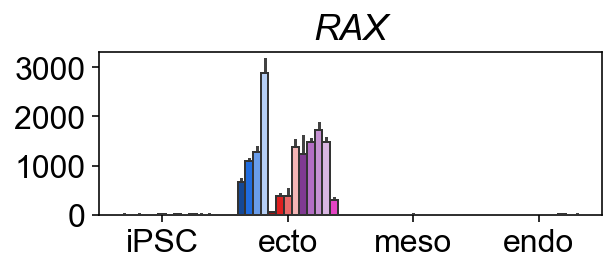

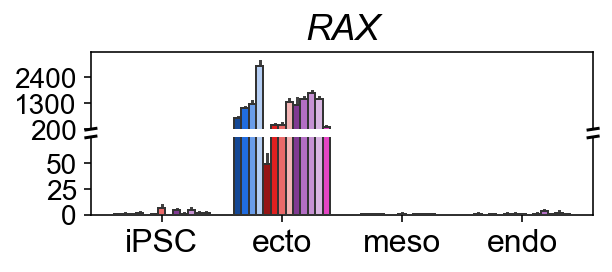

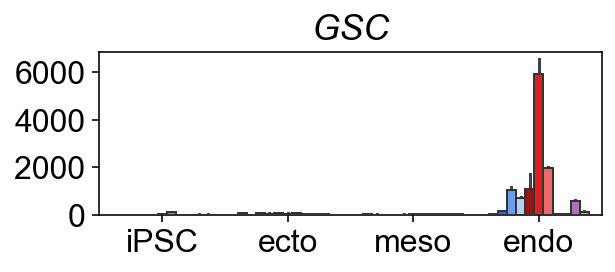

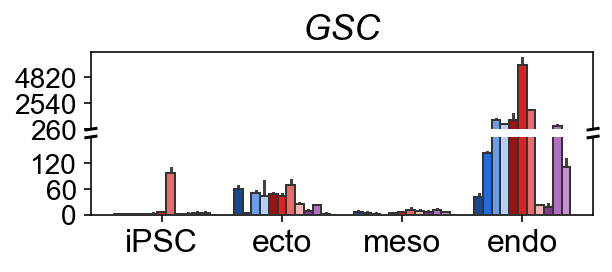

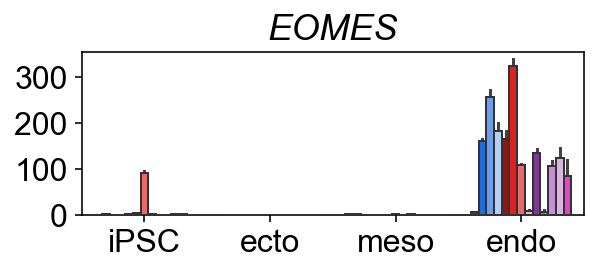

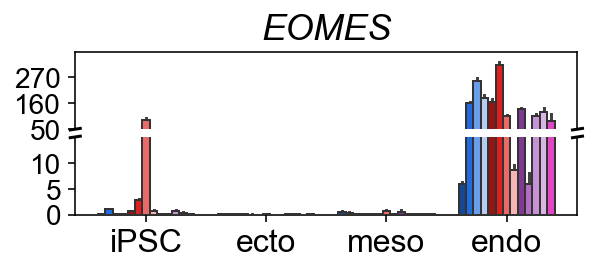

In [10]:
### FOR MAIN TEXT FIGURE FOR PAPER ###

if not onlyTwoTissues:
    #figsize(5.5,3.5)
    #figsize(8.5,3.5)
    #figsize(10.5,3.5)
    #figsize(5,1.5)
    figsize(4.5,1.5)

if onlyTwoTissues:
    figsize(3, 1.5)
if suppFig:
    figsize(4.5, 1.5)

i = 0
for gene in genes:

  # SAVE THE LEGEND ALONE
    if i == 0:
        sns.barplot(x=toPlotOnX, y=toPlotOnY, hue=toColor, 
                data=plotting_df[plotting_df['Target']==gene],
                palette=paletteForAll, edgecolor=".2")
        legend = plt.legend(ncol=num_cols_in_legend, bbox_to_anchor=(1.04,1), prop={'size':30})
        fig  = legend.figure
        fig.canvas.draw()
        bbox  = legend.get_window_extent()
        bbox = bbox.from_extents(*(bbox.extents + np.array([-5,-5,5,5])))
        bbox = bbox.transformed(fig.dpi_scale_trans.inverted())
        
        fig.savefig('LEGEND.pdf', bbox_inches=bbox)
        
        plt.close()
        #plt.show()

        # print legend to screen
        pal = sns.color_palette(paletteForAll)
        colors = [color for color in pal.as_hex()]
        plt.figure()
        patches = [
            mpatches.Patch(color=color, label=cellLine)
            for cellLine, color in zip(cellLines, colors)]
        plt.legend(patches, cellLines, loc='center', frameon=False, edgecolor=".2")
        plt.axis('off')
        plt.show()
        plt.axis('on')
        i += 1

    # MAKE PLOT WITHOUT BROKEN Y
    # Best for NANOG, DNMT3B, TUBB3
    if gene != 'DLK1':
        sns.barplot(x=toPlotOnX, y=toPlotOnY, hue=toColor, 
                  data=plotting_df[plotting_df['Target']==gene],
                  palette=paletteForAll, errwidth=errorBarWidth, zorder=5, edgecolor=".2")
        plt.xlabel('')
        plt.ylabel('')
        #plt.ylabel(forFigureName)
        plt.title(gene, **title_font, style='italic')
        #plt.legend(loc=(1.02,0.04))
        plt.legend('', frameon=False)
        plt.xticks(**x_font)
        plt.yticks(**y_font)
        #if gene in ['NANOG', 'DNMT3B']:
        plt.savefig(gene+'_'+forFigureName+'_supplement.pdf', bbox_inches='tight')
        plt.show()

    if not suppFig:
        # MAKE PLOT WITH BROKEN Y
        # Best for PAX6, TBXT, HAND1, FOXA2, GSC
        if gene in brokenY_axis_limits:
            bottomAxisLower, bottomAxisUpper, topAxisLower, topAxisUpper = brokenY_axis_limits[gene]
            broken_y_bar_ALLcellLines(plotting_df[plotting_df['Target']==gene], 
                                      bottomAxisLower, bottomAxisUpper, 
                                      topAxisLower, topAxisUpper, gene)
        #plt.xticks(**axis_font)
        #plt.yticks(**axis_font)

        plt.savefig(gene+'_'+forFigureName+'_brokenY_ALL.pdf', bbox_inches='tight')

        plt.show()

In [ ]:
plotting_df.columns

In [ ]:
comparisons_list = []
uncor_p_list = []
uncor_bool_list = []
iPSC_mean_list = []
iPSC_sd_list = []
tissue_mean_list = []
tissue_sd_list = []

tissuesOfInterest = {'NANOG':['ecto', 'meso', 'endo'],
                    'DNMT3B':['ecto', 'meso', 'endo'],
                    'PAX6':['ecto'],
                    'RAX':['ecto'],
                    'TBXT':['meso'],
                    'HAND1':['meso'],
                    'FOXA2':['endo'],
                    'SOX17':['endo']}

colOfInterest = 'Relative Expression (to H20961 iPS)'

tissueTypeList = [x for x in list(set(plotting_df['Biogroup'])) if x != 'iPSC']

for cellLine in set(plotting_df['Cell Line']):
    #print(cellLine)
    for gene in set(plotting_df['Target']):
        if gene not in tissuesOfInterest:
            continue
        iPSC_list = plotting_df[(plotting_df['Cell Line']==cellLine) & (plotting_df['Biogroup']=='iPSC') & (plotting_df['Target']==gene)][colOfInterest]
        iPSC_mean = mean(iPSC_list)
        iPSC_sd = statistics.stdev(iPSC_list)
        #display(iPSC_df)
        for tissue in tissueTypeList:
            if tissue in tissuesOfInterest[gene]:
                #print(gene, tissue)
                tissue_list = plotting_df[(plotting_df['Cell Line']==cellLine) & (plotting_df['Biogroup']==tissue) & (plotting_df['Target']==gene)][colOfInterest]
                #display(tissue_df)
                comparisons_list.append(cellLine+'_'+gene+'_'+tissue)
                tissue_mean = mean(tissue_list)
                tissue_sd = statistics.stdev(tissue_list)
                tissue_mean_list.append(tissue_mean)
                tissue_sd_list.append(tissue_sd)
                iPSC_mean_list.append(iPSC_mean)
                iPSC_sd_list.append(iPSC_sd)
                stat, uncor_p = stats.ttest_ind(iPSC_list, tissue_list, nan_policy='omit')
                uncor_p_list.append(uncor_p)
                
                if uncor_p <= 0.05:
                    uncor_bool_list.append(True)
                else:
                    uncor_bool_list.append(False)
                
    
cor_bool_list, cor_p_list, alphacSidak,alphacBonf = multipletests(uncor_p_list, alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)


with open('TLD_results_suppTable.txt', 'w') as outFile:
#print("2-tailed Student's t-test results, FDR 5%")
    print('cell line', 
          'marker gene', 
          'tissue type in which marker gene is expected to be expressed', 
          'tissue type comparison for p-value calculation', 
          'mean expression in differentiated tissue type (relative to H2 iPSC)', 
          'mean expression in iPSC (relative to H2 iPSC)', 
          'standard deviation of expression in differentiated tissue type',
          'standard deviation of expression in iPSC',
          "uncorrected p-value (two-tailed Student's t-test)",
          'corrected p-value (5% FDR)',
          'significant?', sep='\t', file=outFile)
    for comparison, uncor_p, cor_p, uncor_bool, cor_bool, iPSC_mean, iPSC_sd, tissue_mean, tissue_sd in zip(comparisons_list, uncor_p_list, cor_p_list, uncor_bool_list, cor_bool_list, iPSC_mean_list, iPSC_sd_list, tissue_mean_list, tissue_sd_list):
        #if cor_bool == False:
            cell_line, gene, tissue = comparison.split('_')
            if gene in ['NANOG', 'DNMT3B']:
                tissueInWhichExpectedExpression = 'iPSC'
            else:
                tissueInWhichExpectedExpression = tissuesOfInterest[gene][0]

            vsStatement = tissue + ' v. ' + 'iPSC'
            print(cell_line, gene, tissueInWhichExpectedExpression, vsStatement, tissue_mean, iPSC_mean, tissue_sd, iPSC_sd, uncor_p, cor_p, cor_bool, sep='\t', file=outFile)


In [ ]:
toFindMaxSig_list = []
for comparison, uncor_p, cor_p, uncor_bool, cor_bool in zip(comparisons_list, uncor_p_list, cor_p_list, uncor_bool_list, cor_bool_list):
    if cor_bool == True:
        #print(comparison, uncor_p, cor_p, uncor_bool, cor_bool)
        toFindMaxSig_list.append(cor_p)
        
print(max(toFindMaxSig_list))
len(toFindMaxSig_list)

In [ ]:
plotting_df[(plotting_df['Cell Line']=='C1C1a') & (plotting_df['Biogroup']=='iPSC') & (plotting_df['Target']=='PAX6')][colOfInterest]

In [ ]:
plotting_df[(plotting_df['Cell Line']=='C1C1a') & (plotting_df['Biogroup']=='ecto') & (plotting_df['Target']=='PAX6')][colOfInterest]

In [ ]:
stats.ttest_ind([3.554236, 2.536324, 2.746090], [1472.622851, 889.650279, 3309.292782])

In [ ]:
mean([3.554236, 2.536324, 2.746090])

In [ ]:
import statistics
statistics.stdev([3.554236, 2.536324, 2.746090])

In [ ]:
math.sd